# Module 3

First we import the libraries and the data path of the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib
from typing import Tuple

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, auc
from sklearn.pipeline import make_pipeline

plt.style.use("fast")

def find_project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / 'pyproject.toml').exists():
            return parent
    raise FileNotFoundError('pyproject.toml is not in project root')

PROJECT_ROOT = find_project_root()
data_path = PROJECT_ROOT / 'data/raw' # data is loaded in this folder

We load the data in a dataframe.

In [23]:
feature_frame = pd.read_csv(f"{data_path}/feature_frame.csv")
df = feature_frame

We run head and info as it give us some crucial information to continue with our project.

In [24]:
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

We filter by only the orders that are big enugh and profitable.

In [26]:
# here we are filtering by users that purchase the promoted item as part of a basket of at least 5 items.
min_products = 5 # We can change this value if we needed
order_size = df.groupby("order_id").outcome.sum()
orders_of_min_size = order_size[order_size >= min_products].index

# Apply the filter to the dataframe
df_filtered = df[df["order_id"].isin(orders_of_min_size)]

print(f"Orders before: {df['order_id'].nunique()}, after: {df_filtered['order_id'].nunique()}")
print(f"Rows before: {len(df)}, after: {len(df_filtered)}")
df.order_id.nunique() > df_filtered.order_id.nunique()

Orders before: 3446, after: 2603
Rows before: 2880549, after: 2163953


True

We see some columns which aren't relevant to our model as they are purely informational (id & date). Such as variant_id, order_id, user_id, created_at and order_date. 
Then our prediction columns is outcome

In [27]:
info_columns = ["variant_id", "order_id", "user_id", "created_at", "order_date"]
label_column = "outcome"
feature_columns = [
    "product_type", "user_order_seq",  "ordered_before", "abandoned_before", "active_snoozed", "set_as_regular", "normalised_price",
     "discount_pct", "vendor", "global_popularity", "count_adults", "count_children", "count_babies", "count_pets", "people_ex_baby", 
      "days_since_purchase_variant_id", "avg_days_to_buy_variant_id", "std_days_to_buy_variant_id", "days_since_purchase_product_type",
        "avg_days_to_buy_product_type", "std_days_to_buy_product_type"]

categoric_columns = ["product_type", "vendor"]
binary_columns = ["ordered_before", "abandoned_before", "active_snoozed", "set_as_regular"]

numerical_cols = [col for col in feature_columns if col not in (categoric_columns + [binary_columns])]

We say in df.info() that order_date & created_at are set as object when they really should be datetime. We fix this as we see below:

In [28]:
df_filtered["order_date"] = pd.to_datetime(df_filtered["order_date"])
df_filtered["created_at"] = pd.to_datetime(df_filtered["created_at"])

/tmp/ipykernel_2197/3465976923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["order_date"] = pd.to_datetime(df_filtered["order_date"])
/tmp/ipykernel_2197/3465976923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["created_at"] = pd.to_datetime(df_filtered["created_at"])


# Milestone 1: exploration phase



In [29]:
daily_orders = df_filtered.groupby("order_date").order_id.nunique()

In [30]:
daily_orders.head()

order_date
2020-10-05     3
2020-10-06     7
2020-10-07     6
2020-10-08    12
2020-10-09     4
Name: order_id, dtype: int64

Text(0.5, 1.0, 'Daily Orders')

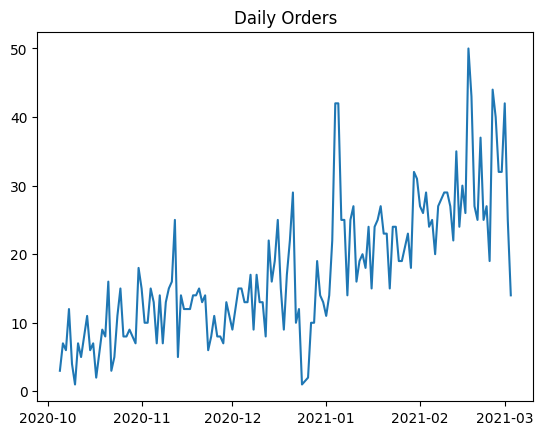

In [31]:
plt.plot(daily_orders, label = "daily_orders")
plt.title("Daily Orders")

Given the company's significant growth trajectory, it would be incorrect to assume that purchasing dynamics remain stationary throughout the observation period. These dynamics are likely to shift in tandem with business evolution. Accordingly, the dataset will be partitioned using a temporal split strategy to prevent any form of information leakage.

Text(0.5, 1.0, 'Cumulative Daily Orders')

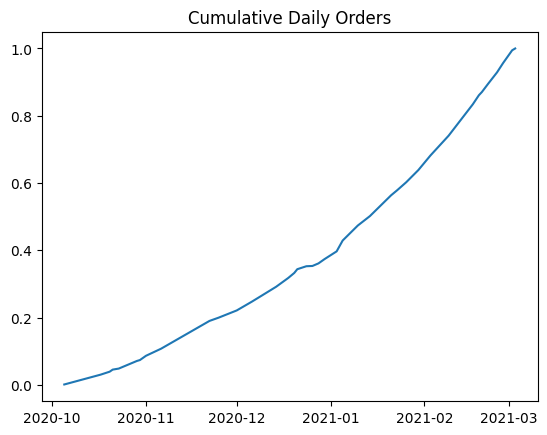

In [32]:
cum_sum_daily_orders = daily_orders.cumsum() / daily_orders.sum()
plt.plot(cum_sum_daily_orders)
plt.title("Cumulative Daily Orders")

In [ ]:
# Split at ~70% to keep the entire Valentine's Day period in the validation set
cutoff_train = cum_sum_daily_orders[cum_sum_daily_orders <= 0.70].index[-1]
cutoff_val   = cum_sum_daily_orders[cum_sum_daily_orders <= 0.90].index[-1]

df_train = df_filtered[df_filtered["order_date"] <= cutoff_train]
df_val   = df_filtered[(df_filtered["order_date"] > cutoff_train) & (df_filtered["order_date"] <= cutoff_val)]
df_test  = df_filtered[df_filtered["order_date"] > cutoff_val]

print(f"Train: {df_train['order_date'].min().date()} → {df_train['order_date'].max().date()}")
print(f"Val:   {df_val['order_date'].min().date()} → {df_val['order_date'].max().date()}")
print(f"Test:  {df_test['order_date'].min().date()} → {df_test['order_date'].max().date()}")

Train: 2020-10-05 → 2021-02-04
Val:   2021-02-05 → 2021-02-22
Test:  2021-02-23 → 2021-03-03


# Baseline

To assess whether our ML model provides meaningful value, we compare it against a 
training-free baseline. We use `global_popularity` as our baseline feature, given that 
exploratory data analysis identified it as one of the most influential numerical predictors.

We also need to establish an evaluation framework for comparing models. Given the inherent 
trade-off between the volume of push notifications sent and the resulting uplift in sales, 
we will assess model performance using the **ROC curve** and the **Precision-Recall curve**.

In [34]:
def plot_metrics(
        model_name: str,
        y_pred: pd.Series,
        y_test: pd.Series,
        target_precision: float = 0.05,
        figure: Tuple[matplotlib.figure.Figure, np.array] = None
) -> None:
    if figure is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        show = True
    else:
        fig, axes = figure
        show = False

    # Only draw reference lines once
    if not axes[0].lines:
        axes[0].plot([0, 1], [0, 1], "k--", label="Random")
    if not axes[1].lines:
        axes[1].axhline(y=target_precision, color="r", linestyle="--", label=f"Target precision ({target_precision})")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f"{model_name} (AUC = {pr_auc:.3f})")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()

    plt.tight_layout()

    if show:
        plt.show()

We first evaluate the baseline model using `global_popularity` as the prediction score, 
against the validation set. This gives us a reference benchmark that any trained model 
must surpass to justify its added complexity.

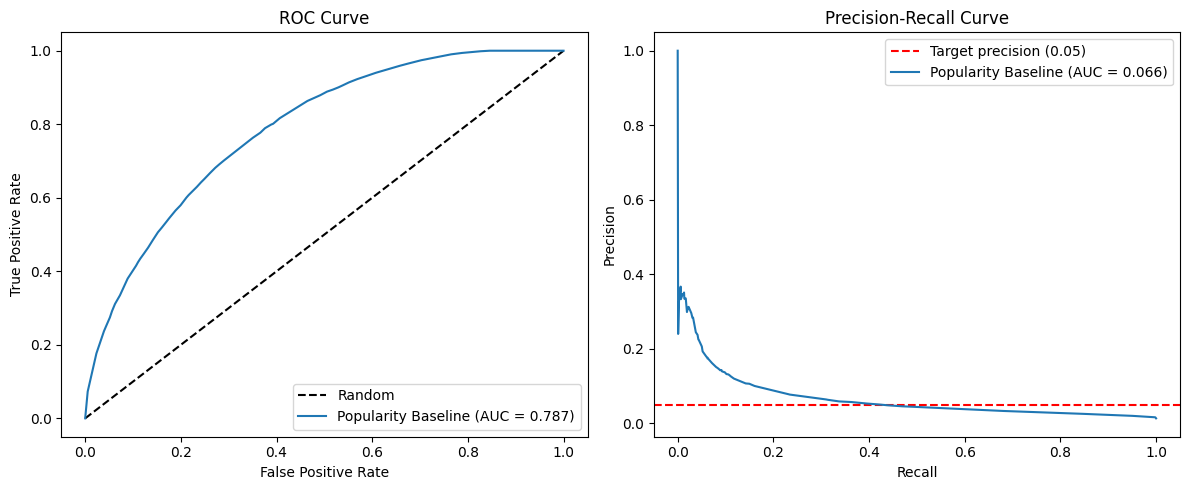

In [35]:
plot_metrics("Popularity Baseline", y_pred=df_val["global_popularity"], y_test=df_val[label_column])

Now we can move on into training models

# Models

In [36]:
X_train, y_train = df_train[feature_columns], df_train[label_column]

X_val, y_val = df_val[feature_columns], df_val[label_column]

X_test, y_test = df_test[feature_columns], df_test[label_column]

As an initial approach, we restrict the feature set to numerical and binary columns, 
excluding categorical variables. We will incorporate the categorical features in a 
subsequent iteration, but only if they yield a measurable improvement in model performance.

In [37]:
train_cols = numerical_cols + binary_columns

##### Ridge Regression

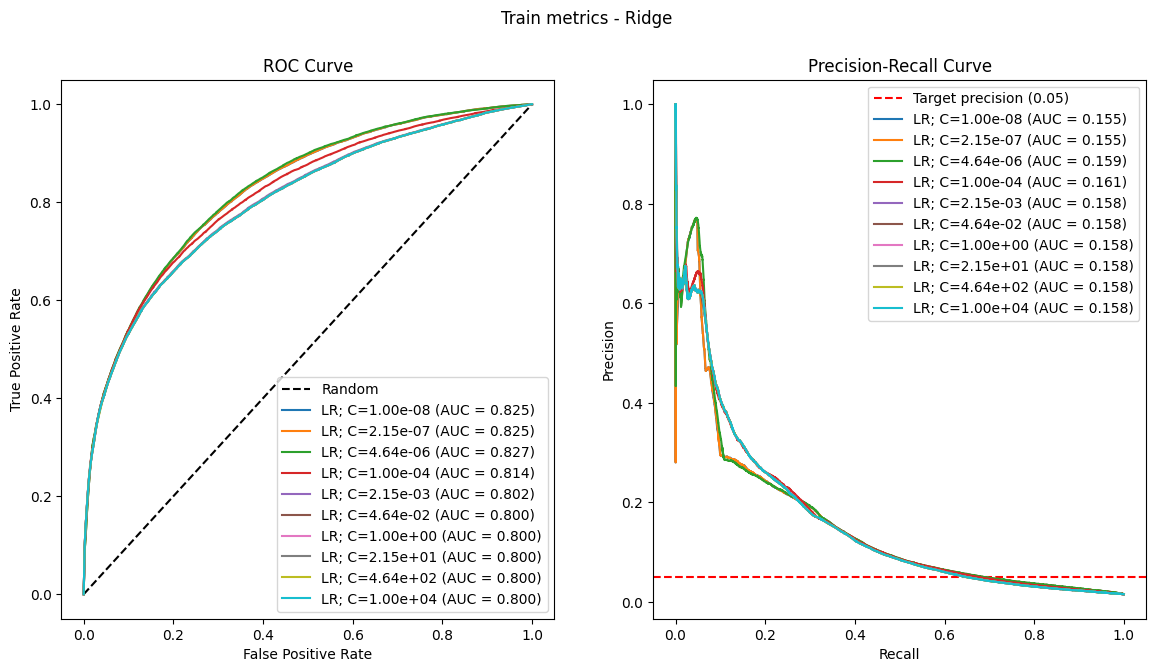

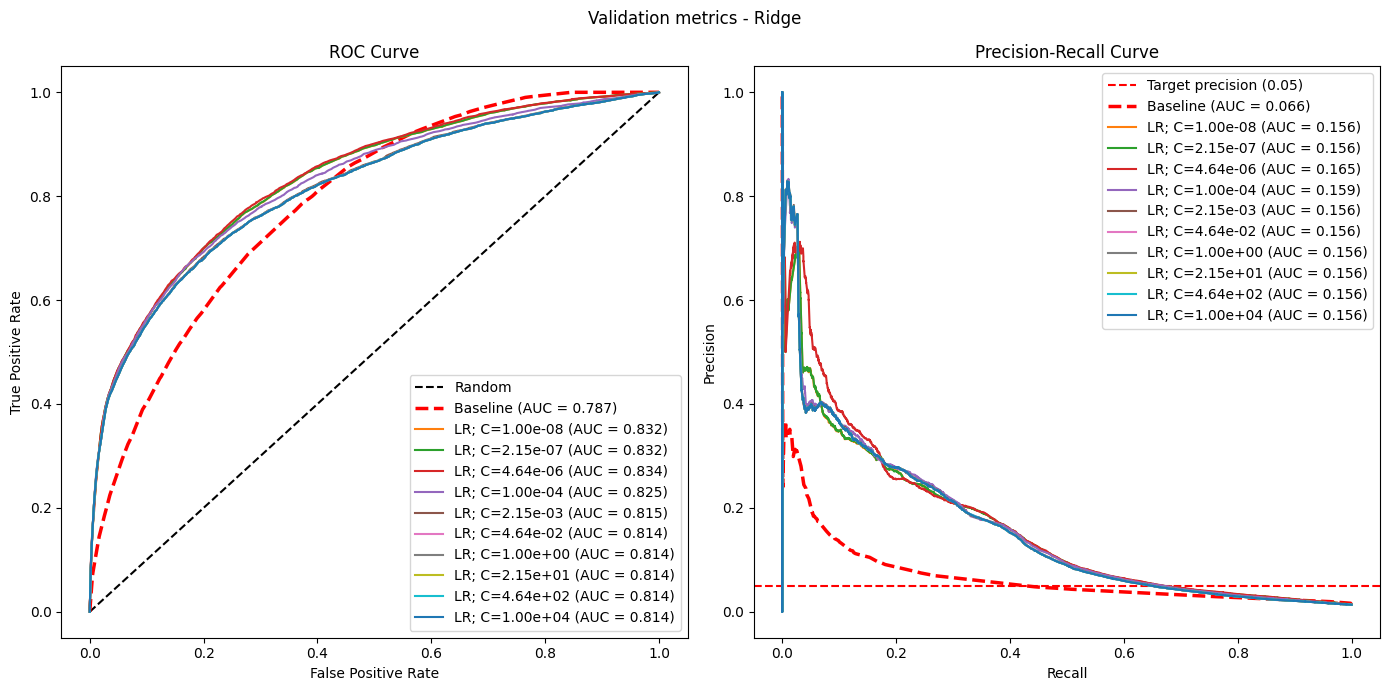

In [46]:
from sklearn.preprocessing import StandardScaler

fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train metrics - Ridge")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation metrics - Ridge")

C_values = np.logspace(-8, 4, 10)

# Baseline first so it's always visible
plot_metrics("Baseline", y_pred=df_val["global_popularity"], y_test=y_val, figure=(fig2, ax2))
for ax in ax2:
    ax.get_lines()[-1].set(color="red", linewidth=2.5, linestyle="--")

for C in C_values:
    label = f"LR; C={C:.2e}"
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=C, max_iter=1000, solver="saga")
    )
    model.fit(X_train[train_cols], y_train)

    train_proba = model.predict_proba(X_train[train_cols])[:, 1]
    plot_metrics(label, y_pred=train_proba, y_test=y_train, figure=(fig1, ax1))

    val_proba = model.predict_proba(X_val[train_cols])[:, 1]
    plot_metrics(label, y_pred=val_proba, y_test=y_val, figure=(fig2, ax2))

plt.show()

#### Results

Focusing on the Precision-Recall curve, the Logistic Regression model significantly 
outperforms the baseline across all values of `C` (PR AUC ~0.16 vs 0.066 for the baseline), 
confirming that the model captures meaningful purchasing patterns beyond simple popularity.

A few notable observations:

- **Regularization has little impact**: the PR curves are nearly identical across all `C` values, 
suggesting the model is not sensitive to the strength of regularization. This likely means 
the signal in the numerical and binary features is strong enough that penalization does not 
meaningfully constrain the solution.

- **No overfitting**: train and validation metrics are consistent, which is a good sign given 
the size of the dataset.

- **Room for improvement**: the PR AUC of ~0.16 is modest. The sharp precision drop at low 
recall values suggests the model struggles to rank the most relevant items confidently. 
Incorporating categorical features (`product_type`, `vendor`) in the next iteration may 
help capture additional signal.

##### Lasso Regression

/home/tomas/.cache/pypoetry/virtualenvs/zrive-ds-kXjcYw89-py3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


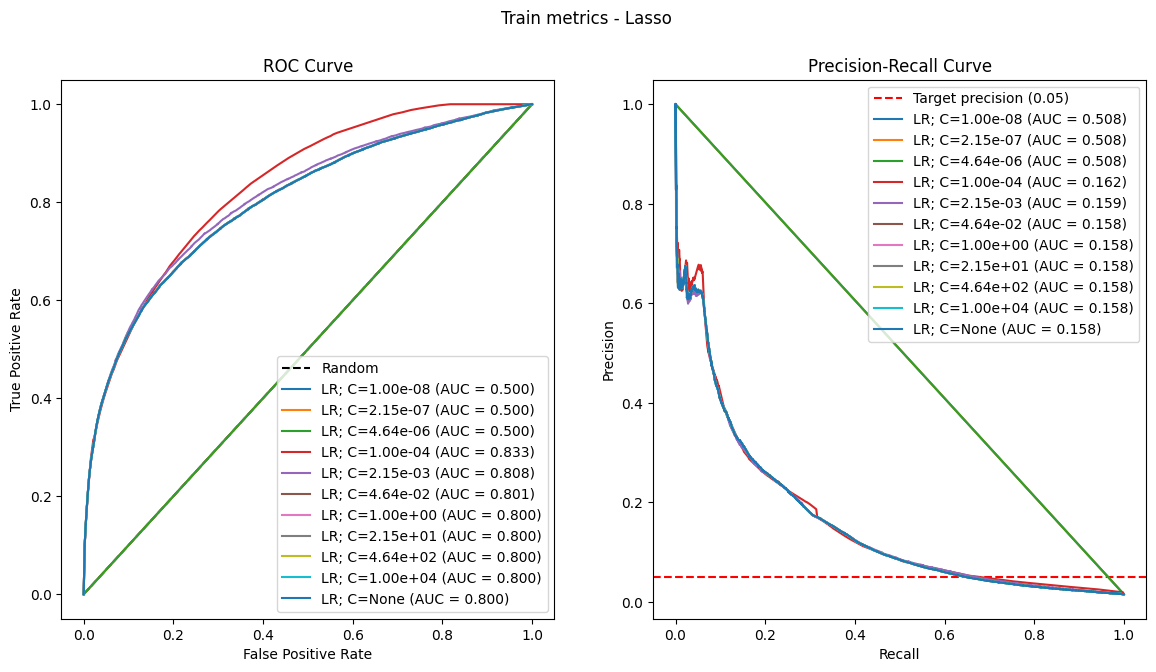

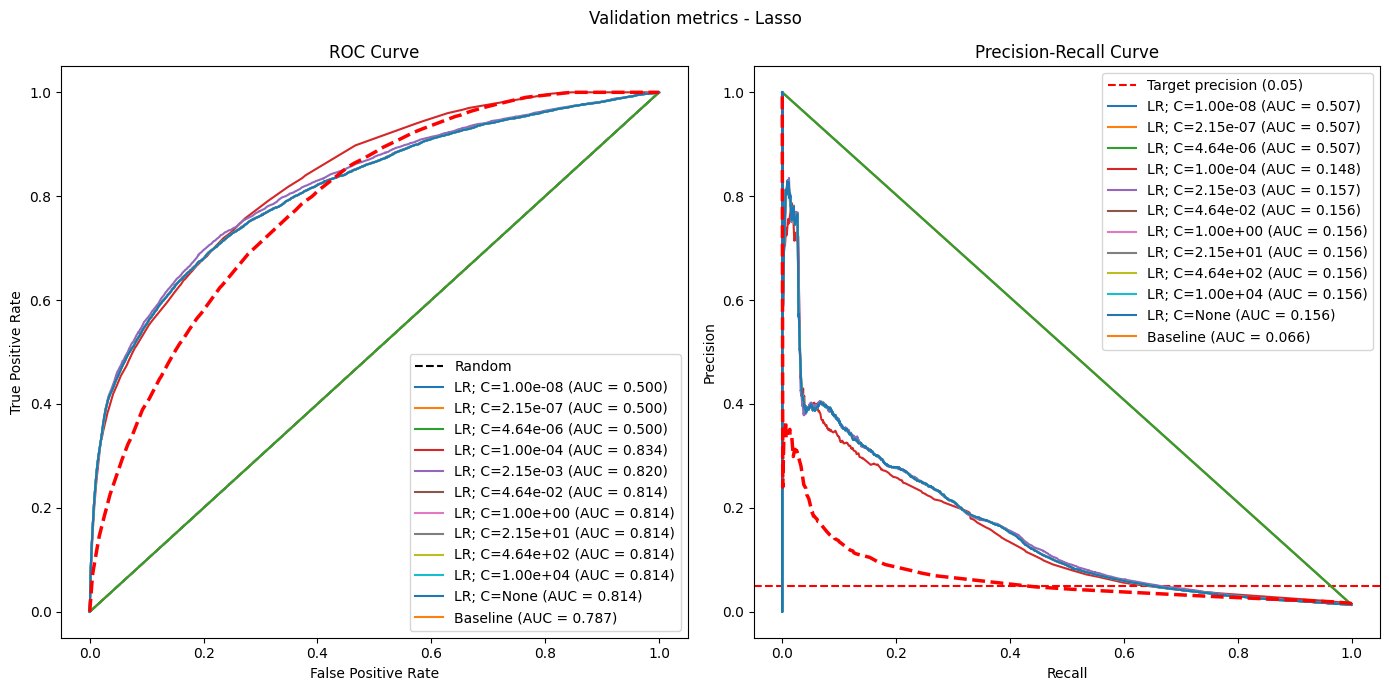

In [42]:
fig3, ax3 = plt.subplots(1, 2, figsize=(14, 7))
fig3.suptitle("Train metrics - Lasso")

fig4, ax4 = plt.subplots(1, 2, figsize=(14, 7))
fig4.suptitle("Validation metrics - Lasso")

C_values = [*np.logspace(-8, 4, 10), None]  # 1/alpha

for C in C_values:
    label = f"LR; C={C:.2e}" if C else "LR; C=None"
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=C if C else 1.0, max_iter=1000, solver="saga")
    )
    model.fit(X_train[train_cols], y_train)

    train_proba = model.predict_proba(X_train[train_cols])[:, 1]
    plot_metrics(label, y_pred=train_proba, y_test=y_train, figure=(fig3, ax3))

    val_proba = model.predict_proba(X_val[train_cols])[:, 1]
    plot_metrics(label, y_pred=val_proba, y_test=y_val, figure=(fig4, ax4))

plot_metrics(
    "Baseline",
    y_pred=df_val["global_popularity"],
    y_test=y_val,
    figure=(fig4, ax4)
)
for ax in ax4:
    ax.get_lines()[-1].set(color="red", linewidth=2.5, linestyle="--")

plt.show()

#### Results - Lasso

The Lasso results reveal two distinct behaviours depending on the regularization strength:

- **Very low `C` values (C ≤ 1e-6)**: the straight diagonal line in both the ROC and 
Precision-Recall curves indicates that the model is **degenerate** — the regularization 
is so strong that it drives all coefficients to zero, causing the model to predict the 
same value for every sample (all 0s or all 1s). This is a known failure mode of L1 
regularization when over-constrained.

- **Moderate to high `C` values (C ≥ 1e-4)**: the model recovers and performs comparably 
to Ridge (~0.156 PR AUC), confirming that once regularization is relaxed, Lasso finds 
a similar solution.

As with Ridge, performance is **stable across a wide range of `C` values**, which suggests 
that regularization is not a critical factor here. With over 2 million rows, the dataset 
is large enough that overfitting is unlikely — the model generalises well regardless of 
the penalty strength.

Overall, **Lasso offers no clear advantage over Ridge** in this setting, as the feature 
selection property of L1 is less relevant when the dataset is this large and the number 
of features is relatively small.

#### Coefficient Weights - Ridge vs Lasso

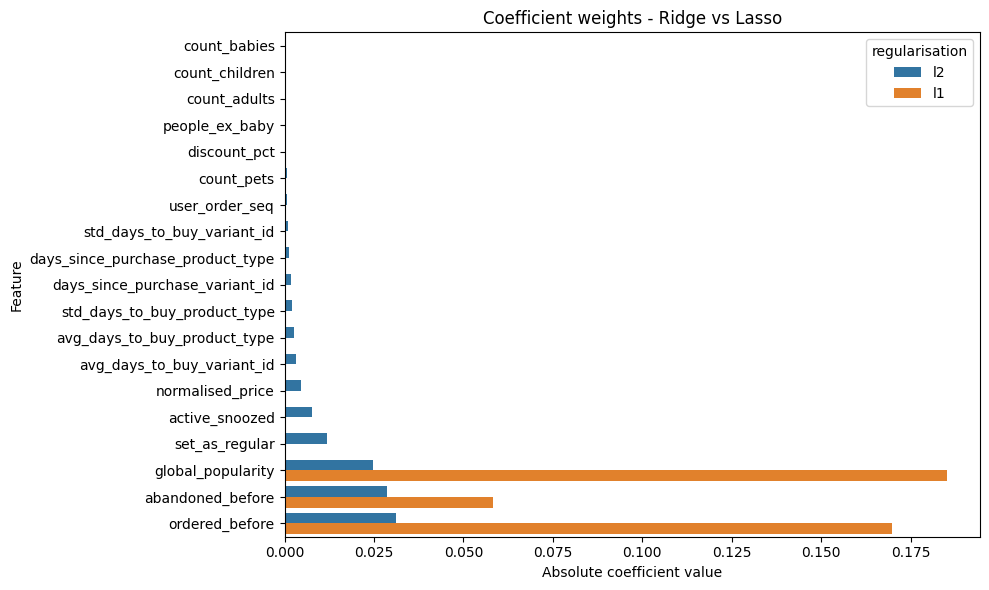

In [40]:
from sklearn.pipeline import Pipeline
# Coefficient weights for Ridge (L2)
lr_l2 = Pipeline([
    ("standard_scaler", StandardScaler()),
    ("lr", LogisticRegression(penalty="l2", C=1e-6, max_iter=1000, solver="saga"))
])
lr_l2.fit(X_train[train_cols], y_train)
lr_coeff_l2 = pd.DataFrame({
    "features": train_cols,
    "importance": np.abs(lr_l2.named_steps["lr"].coef_[0]),
    "regularisation": ["l2"] * len(train_cols)
})
lr_coeff_l2 = lr_coeff_l2.sort_values("importance", ascending=True)

# Coefficient weights for Lasso (L1)
lr_l1 = Pipeline([
    ("standard_scaler", StandardScaler()),
    ("lr", LogisticRegression(penalty="l1", C=1e-4, max_iter=1000, solver="saga"))
])
lr_l1.fit(X_train[train_cols], y_train)
lr_coeff_l1 = pd.DataFrame({
    "features": train_cols,
    "importance": np.abs(lr_l1.named_steps["lr"].coef_[0]),
    "regularisation": ["l1"] * len(train_cols)
})
lr_coeff_l1 = lr_coeff_l1.sort_values("importance", ascending=True)

# Plot both together
lr_coeff = pd.concat([lr_coeff_l2, lr_coeff_l1])

plt.figure(figsize=(10, 6))
sns.barplot(data=lr_coeff, x="importance", y="features", hue="regularisation", orient="h")
plt.title("Coefficient weights - Ridge vs Lasso")
plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The three most influential features are **`ordered_before`** , **`global_popularity`**, **`abandoned_before`**
consistent with our EDA findings. Lasso concentrates almost all weight on these two, 
driving the remaining coefficients to zero, while Ridge distributes weight more evenly 
across all features — retaining some signal from `abandoned_before`, `set_as_regular` 
and `active_snoozed`. Household features and `discount_pct` contribute negligibly in 
both cases.

We now retrain the models restricting the feature set to the three most influential 
predictors identified above: `ordered_before`, `global_popularity` and `abandoned_before`. 
This serves a dual purpose — first, to assess whether a simpler model can match the 
performance of the full feature set, and second, to improve interpretability.

#### Retrain Models

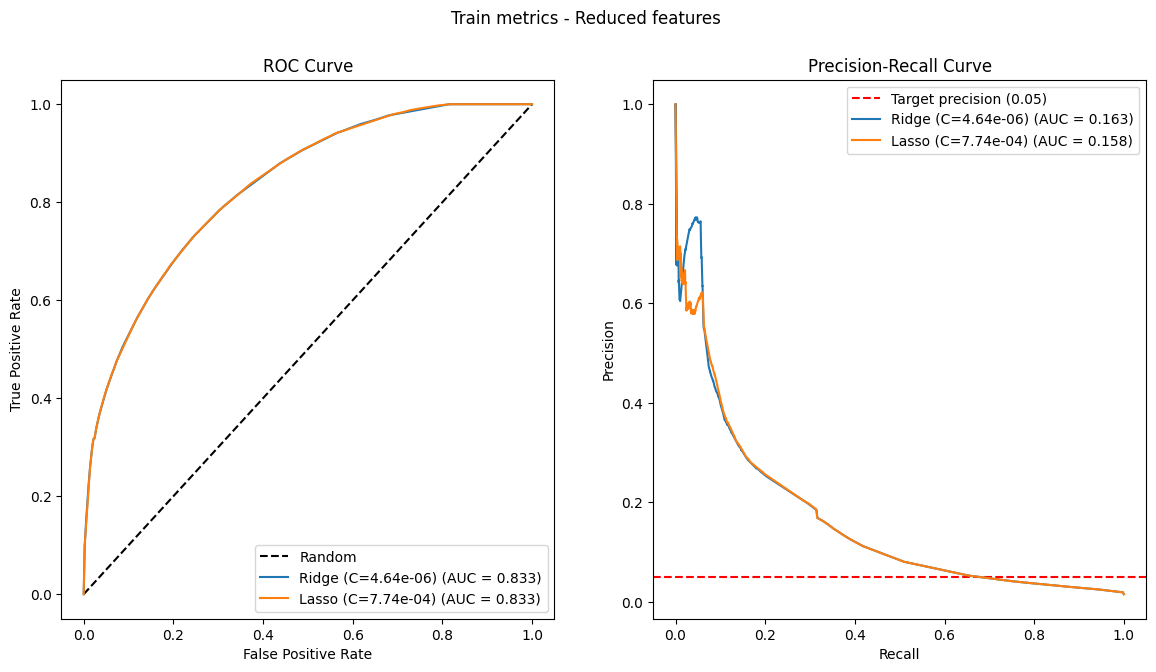

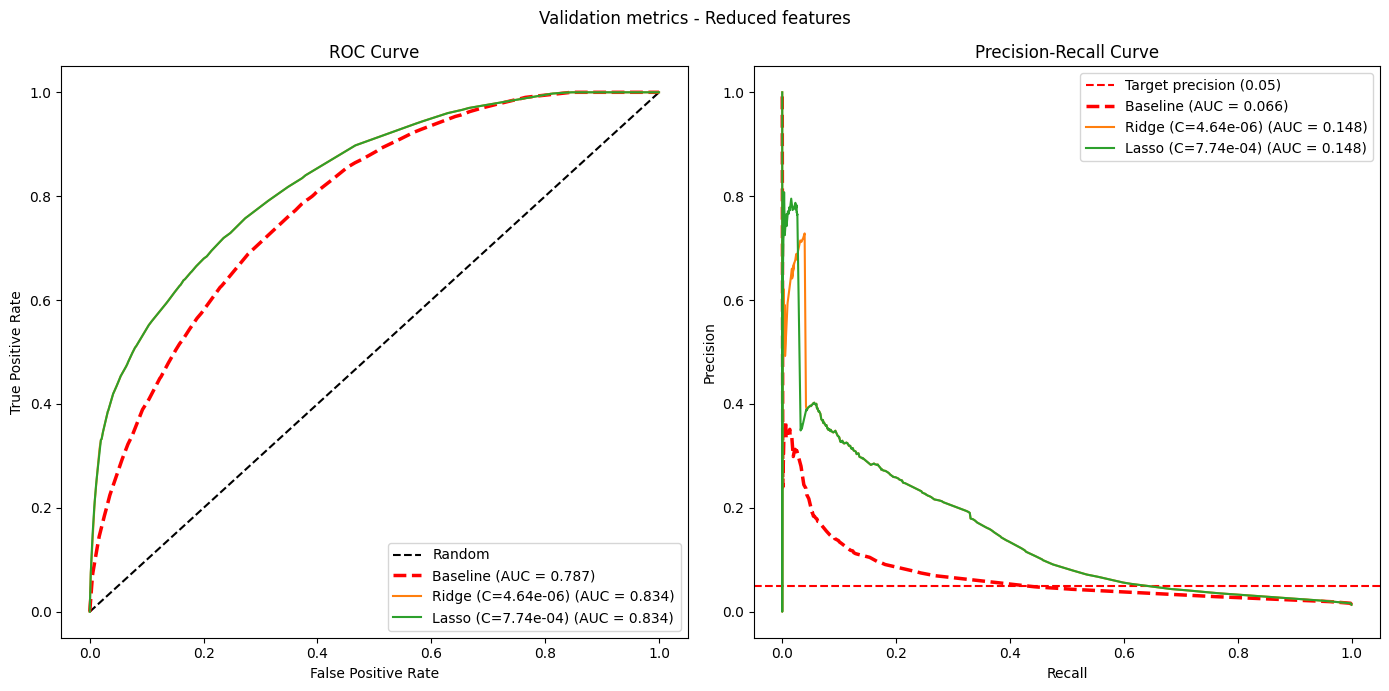

In [45]:
reduced_cols = ["ordered_before", "global_popularity", "abandoned_before"]
C_values_ridge = np.logspace(-8, 4, 10)
C_values_lasso = np.logspace(-4, 4, 10)  # avoid degenerate models

# Find best C for Ridge and Lasso based on val PR AUC
best_ridge = {"C": None, "auc": 0, "train_proba": None, "val_proba": None}
best_lasso = {"C": None, "auc": 0, "train_proba": None, "val_proba": None}

for C in C_values_ridge:
    ridge = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=C, max_iter=1000, solver="saga")
    )
    ridge.fit(X_train[reduced_cols], y_train)
    val_proba = ridge.predict_proba(X_val[reduced_cols])[:, 1]
    pr_auc = auc(*precision_recall_curve(y_val, val_proba)[1::-1])
    if pr_auc > best_ridge["auc"]:
        best_ridge = {"C": C, "auc": pr_auc,
                      "train_proba": ridge.predict_proba(X_train[reduced_cols])[:, 1],
                      "val_proba": val_proba}

for C in C_values_lasso:
    lasso = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=C, max_iter=1000, solver="saga")
    )
    lasso.fit(X_train[reduced_cols], y_train)
    val_proba = lasso.predict_proba(X_val[reduced_cols])[:, 1]
    pr_auc = auc(*precision_recall_curve(y_val, val_proba)[1::-1])
    if pr_auc > best_lasso["auc"]:
        best_lasso = {"C": C, "auc": pr_auc,
                      "train_proba": lasso.predict_proba(X_train[reduced_cols])[:, 1],
                      "val_proba": val_proba}

# Plot
fig_train, ax_train = plt.subplots(1, 2, figsize=(14, 7))
fig_train.suptitle("Train metrics - Reduced features")

fig_val, ax_val = plt.subplots(1, 2, figsize=(14, 7))
fig_val.suptitle("Validation metrics - Reduced features")

# Baseline first so it's always visible
plot_metrics("Baseline", y_pred=df_val["global_popularity"], y_test=y_val, figure=(fig_val, ax_val))
for a in ax_val:
    a.get_lines()[-1].set(color="red", linewidth=2.5, linestyle="--")

plot_metrics(f"Ridge (C={best_ridge['C']:.2e})", y_pred=best_ridge["train_proba"], y_test=y_train, figure=(fig_train, ax_train))
plot_metrics(f"Lasso (C={best_lasso['C']:.2e})", y_pred=best_lasso["train_proba"], y_test=y_train, figure=(fig_train, ax_train))

plot_metrics(f"Ridge (C={best_ridge['C']:.2e})", y_pred=best_ridge["val_proba"], y_test=y_val, figure=(fig_val, ax_val))
plot_metrics(f"Lasso (C={best_lasso['C']:.2e})", y_pred=best_lasso["val_proba"], y_test=y_val, figure=(fig_val, ax_val))

plt.show()

#### Results - Reduced Features (Ridge vs Lasso)

Dropping down to just three features barely hurts performance — PR AUC goes from ~0.156 
to 0.148 on validation, which is a small price to pay for a much simpler model.

Ridge and Lasso are essentially the same here, which makes sense: with only 3 features, 
there is nothing for Lasso to select out. Both beat the baseline by a wide margin 
(PR AUC 0.148 vs 0.066), and train/val metrics are consistent so there is no sign of 
overfitting.

Given this, the reduced model is a reasonable choice going forward — it is easier to 
explain, faster to train, and nearly as good as the full one.

### Categorical Encoding

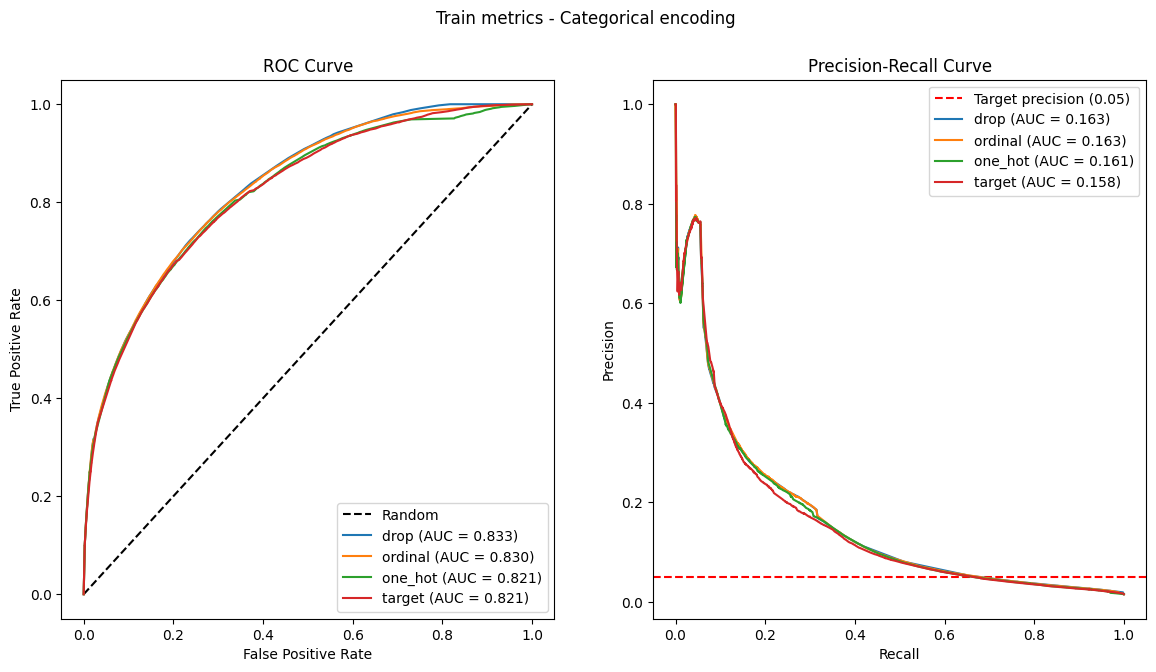

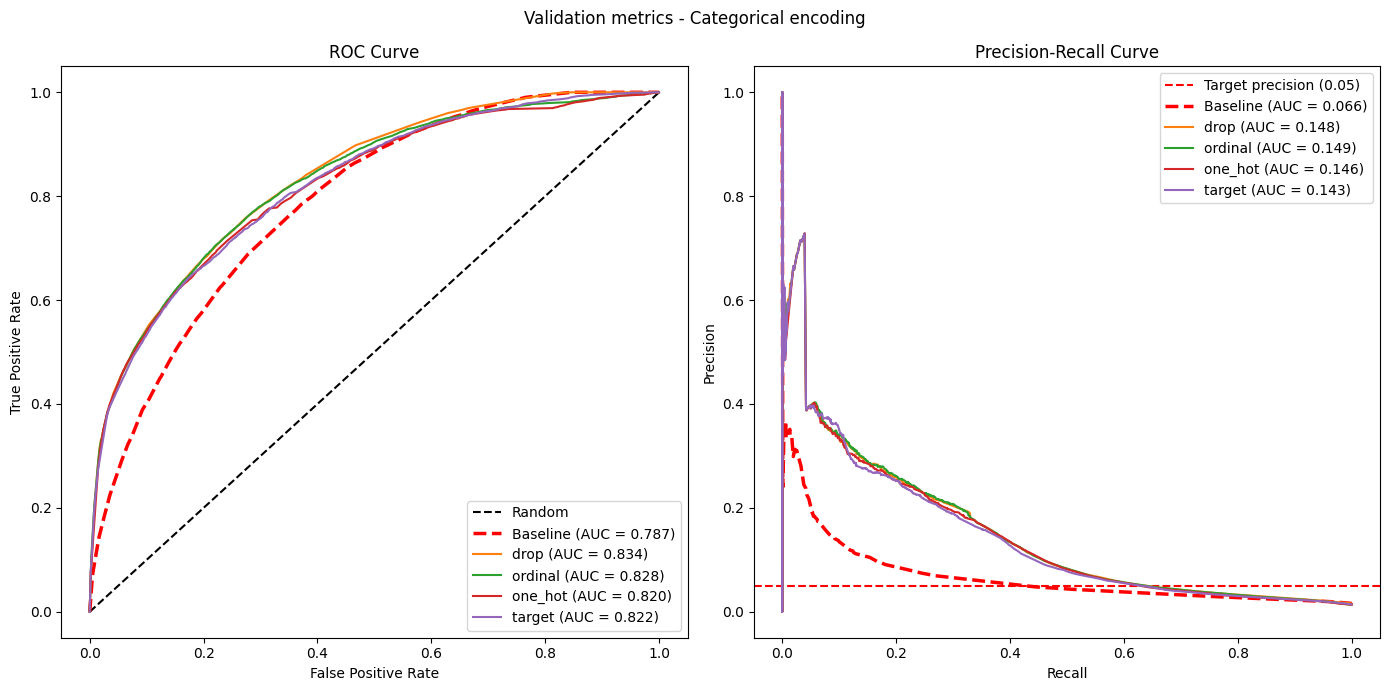

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import TargetEncoder

categorical_preprocessors = [
    ("drop", "drop"),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", max_categories=20, sparse_output=False)),
    ("target", TargetEncoder(target_type="continuous")),
]

fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Train metrics - Categorical encoding")

fig2, ax2 = plt.subplots(1, 2, figsize=(14, 7))
fig2.suptitle("Validation metrics - Categorical encoding")

extended_cols = reduced_cols + categoric_columns

# Baseline first
plot_metrics("Baseline", y_pred=df_val["global_popularity"], y_test=y_val, figure=(fig2, ax2))
for ax in ax2:
    ax.get_lines()[-1].set(color="red", linewidth=2.5, linestyle="--")

for name, categorical_preprocessor in categorical_preprocessors:
    preprocessor = ColumnTransformer([
        ("numerical", "passthrough", reduced_cols),
        ("categorical", categorical_preprocessor, categoric_columns),
    ])
    model = make_pipeline(
        preprocessor,
        StandardScaler(with_mean=False),
        LogisticRegression(penalty="l2", C=1e-6, max_iter=1000, solver="saga")
    )
    model.fit(X_train[extended_cols], y_train)

    train_proba = model.predict_proba(X_train[extended_cols])[:, 1]
    plot_metrics(name, y_pred=train_proba, y_test=y_train, figure=(fig1, ax1))

    val_proba = model.predict_proba(X_val[extended_cols])[:, 1]
    plot_metrics(name, y_pred=val_proba, y_test=y_val, figure=(fig2, ax2))

plt.show()

#### Results - Categorical Encoding

Adding the categorical features doesn't help — all encoding strategies land at roughly 
the same PR AUC (~0.146-0.149) as just dropping them (0.148), so the extra complexity 
is not worth it.

`target` encoding is actually the worst of the four despite being the most sophisticated, 
which suggests it picks up noise from the training set that doesn't carry over to validation.

At this point, the evidence points clearly towards sticking with the three numerical 
features and skipping the categoricals altogether.

# Conclusions

Starting from a simple popularity-based baseline (PR AUC = 0.066), we trained and evaluated 
several Logistic Regression models, progressively refining the feature set.

The key findings are:

- **Three features are enough**: `ordered_before`, `global_popularity` and `abandoned_before` 
capture most of the predictive signal. The full feature set offers only a marginal improvement 
(PR AUC 0.156 vs 0.148) that does not justify the added complexity.

- **Regularisation type doesn't matter much**: Ridge and Lasso perform virtually identically, 
which is expected given the size of the dataset — with over 2 million rows, overfitting is not 
a concern and penalisation has little effect.

- **Categorical features add no value**: none of the encoding strategies (ordinal, one-hot, 
target) improved over simply dropping them, suggesting `product_type` and `vendor` carry 
no additional signal beyond what the three numerical features already capture.

- **The model comfortably beats the baseline**: PR AUC of 0.148 vs 0.066 — more than double — 
confirming that a trained model is worth deploying over a popularity heuristic.

The final recommended model is a **Ridge Logistic Regression trained on `ordered_before`, 
`global_popularity` and `abandoned_before`**, which offers the best trade-off between 
performance, simplicity and interpretability.